# Introduction to Deep Learning [ULTA]

Laker Newhouse (adapted from work by Daniel Moser)

**FIRST STEP**
* Save a copy of this notebook under File > Save a copy in Drive
* Go through the project using your own copy of the notebook

**ONCE YOU HAVE CREATED A COPY**

Welcome!

To help you understand the fundamentals of deep learning, this demo will walk through the steps of building a neural network model for classifying handwritten numbers with accuracy surpassing 95%.

How to get the most out of the project:
* Read each paragraph carefully.
* Before you run code, pause to predict what will happen.
* Read comments in the code to understand what is going on.
* When you encounter an exercise, try to answer it. If you're stuck, ask a friend.

## The Task for the AI

Our goal is to construct and train an artificial neural network on thousands of images of handwritten digits so that it may successfully identify others when presented. The data that will be incorporated is the MNIST database which contains 60,000 images for training and 10,000 test images. We will use the Keras Python API with TensorFlow as the backend.

<img src="https://github.com/AviatorMoser/keras-mnist-tutorial/blob/master/mnist.png?raw=1" >

## Prerequisite Python Modules

First, some software needs to be loaded into the Python environment.

Instructions: To run a code block, hover over it with your mouse. Click the "Play Button." Wait a few seconds until a green checkmark appears. Great, the code has run! The notebook will also tell you how long the code took to run. Make sure to run each code block as you go through the notebook.

In [ ]:
%matplotlib inline

In [ ]:
import numpy as np                   # advanced math library
import matplotlib.pyplot as plt      # functions for making plots
import random                        # for generating random numbers

from keras.datasets import mnist     # MNIST dataset is included in Keras
from keras.models import Sequential  # Model type to be used (Sequential = feedforward neural network)

from keras.layers.core import Dense, Dropout, Activation # Types of layers to be used in our model
from keras.utils import np_utils                         # NumPy related tools

## Loading Training Data

The MNIST dataset is conveniently bundled within Keras, and we can analyze some of its features in Python. Let's load the data, then print out its shape.

In [ ]:
# The MNIST data is split between 60,000 training images (28 x 28 pixels) and 10,000 test images (28 x 28 pixels)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


**What is shape?**

The _shape_ of a list means how long it is.

Example: the shape of `[4, 2, 5, 0]` is `(4,)`.

Example: the shape of `[1, 2, 3, 4, 5, 6]` is `(6,)`.

The shape of a multidimensional list includes all the lengths:

Example: the shape of

```
[[1, 0],
 [0, 1]]
```

is `(2, 2)` because it is a list of `2` arrays of length `2`.

Example: the shape of

```
[[[1, 2], [3, 4]],
 [[5, 6], [7, 8]],
 [[9, 10], [11, 12]]]
```

is `(3, 2, 2)` because it is a list of `3` arrays of shape `(2, 2)`.

Now, look at the code above that we just ran. See the shapes it printed out?

**Exercise**: what does it mean for `X_train`'s shape to be `(60000, 28, 28)`? Explain where each number comes from.

**Exercise**: what does it mean for `Y_train`'s shape to be `(60000,)`? What kind of data is each entry in `Y_train`?

**Seeing the Training Data**

Using matplotlib (a graphing module), we can plot some sample images from the training set directly into this notebook.

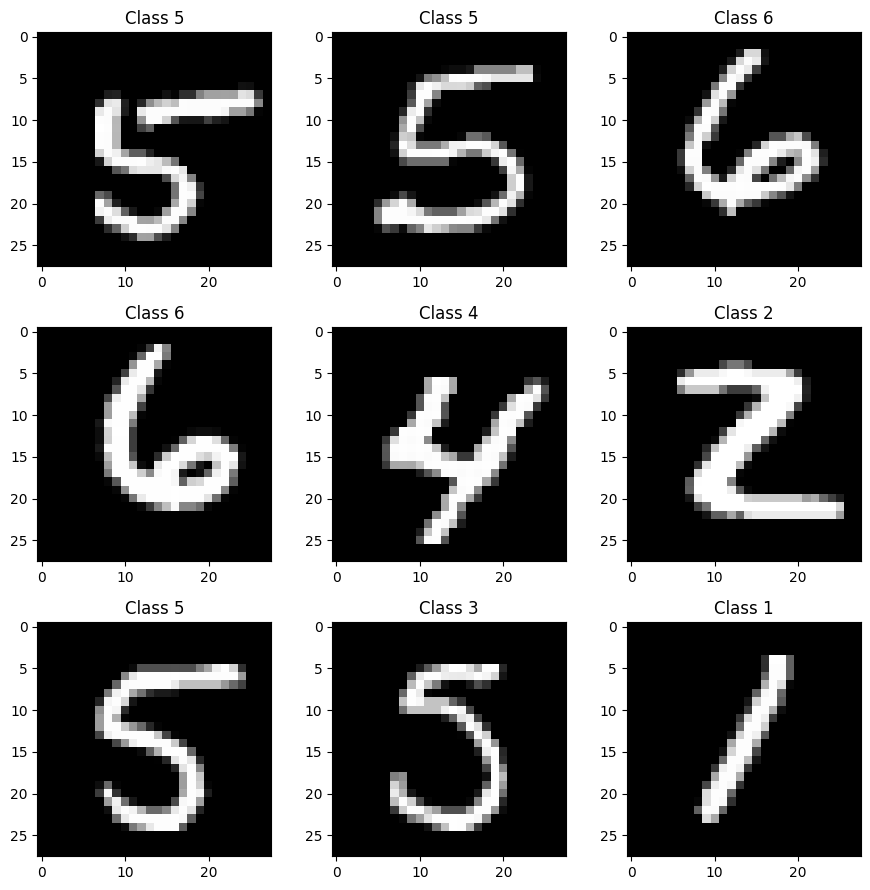

In [ ]:
plt.rcParams['figure.figsize'] = (9,9) # Make the figures a bit bigger

for i in range(9):
    plt.subplot(3,3,i+1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap='gray', interpolation='none')
    plt.title("Class {}".format(y_train[num]))

plt.tight_layout()

**What the Computer Actually Sees**

Let's examine a single digit a little closer and print out the array representing the last digit.

In [ ]:
# just a little function for pretty printing a matrix
def matprint(matrix, fmt="g"):
    col_maxes = [max([len(("{:"+fmt+"}").format(x)) for x in col]) for col in matrix.T]
    for x in matrix:
        for row, value in enumerate(x):
            print(("{:"+str(col_maxes[row])+fmt+"}").format(value), end="  ")
        print("")

# now print!
matprint(X_train[num])

0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0   47  255  255  98  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0   46  253  253  97  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0  104  253  253  97  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0  176  253  223   7  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0   98  246  253  104   0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0 

Each pixel is an integer from 0-255, where 0 is full black and 255 is full white. One channel for color is called monochrome (one color).

*Fun-fact! Your computer screen has three channels for each pixel: red, green, blue. Each of these channels is also an integer from 0-255. That makes 2^24 = 16,777,216 possible colors!*

## Formatting the input data layer

Instead of a 28 x 28 matrix, we want our network to take a length-784 vector. A vector is just a list of numbers, like `(0, 0, 1)`.

Each image needs to be reshaped (or flattened) into a vector. We'll also normalize the inputs to be in the range [0, 1] rather than [0, 255].

<img src='https://github.com/AviatorMoser/keras-mnist-tutorial/blob/master/flatten.png?raw=1' >

In [ ]:
X_train = X_train.reshape(60000, 784) # reshape 60,000 matrices (28 x 28) into 60,000 length-784 vectors.
X_test = X_test.reshape(10000, 784)   # reshape 10,000 matrices (28 x 28) into 10,000 length-784 vectors.

X_train = X_train.astype('float32')   # change integers to 32-bit floating point numbers (for example, 5 becomes 5.0)
X_test = X_test.astype('float32')

X_train /= 255                        # normalize each value for each pixel for the entire vector for each input (for example, 255 becomes 1)
X_test /= 255

print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (60000, 784)
Testing matrix shape (10000, 784)


**Exercise:** Why do we now want the shape of the data to be `(60000, 784)`?

**Exercise:** Where does the number `60000` come from? Where does the number `784` come from?

Now let's modify our classes (unique digits) to be vectors of all zeros with a single 1 (called "one-hot" vectors), that is,

```
0 -> [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1 -> [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
2 -> [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
4 -> [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
5 -> [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
6 -> [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
7 -> [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
8 -> [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
9 -> [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
```

If the final output of our network is very close to one of these classes, then it is most likely that class. For example, if the final output is:

```
[0, 0.94, 0, 0, 0, 0, 0.06, 0, 0]
```
then it is most probable that the image is of the digit `1`. We are formatting our data this way so that we can use negative log loss later on.

In [ ]:
nb_classes = 10 # number of unique digits

Y_train = np_utils.to_categorical(y_train, nb_classes)
Y_test = np_utils.to_categorical(y_test, nb_classes)

# Building a 3-layer fully connected feedforward neural network

Now let's make our neural network. We'll use a network with layers of neurons of (784, 512, 512, 10).

The input and output sizes should stay the same, but feel free to experiment with changing 512 to something else, or adding layers.

<img src="https://github.com/AviatorMoser/keras-mnist-tutorial/blob/master/figure.png?raw=1" />

In [ ]:
# The Sequential model is a linear stack of layers and is very common.
# It's another name for the "feedforward neural network" that we covered in class yesterday.

model = Sequential()

## The first hidden layer

In [ ]:
# The first hidden layer is a set of 512 neurons.
# Each neuron will receive an element from each input neuron and apply some weight and bias to it.
# So the number in the neuron will be w_1 a_1 + ... + w_784 a_784 + b, where
# the weights are numbers called w_1, ..., w_784 and the bias is number called b.

model.add(Dense(512, input_shape=(784,))) #(784,) is not a typo -- that represents a 784 length vector!
# ^^^ what "Dense" means is that each neuron in the second layer is
#     connected to **every** neuron in the first layer

In [ ]:
# An "activation function" is a non-linear function applied to the output of the layer above.
# We also called this a "nonlinearity". It's important to include so the network can do more
# than just add and multiply. Here, we'll use the Rectified Linear Unit function (ReLU).
# It checks the new value of the neuron, and if the value is negative, it makes the value zero.
# Positive values of a neuron are unchanged.

model.add(Activation('relu'))

$$f(x) = max (0,x)$$
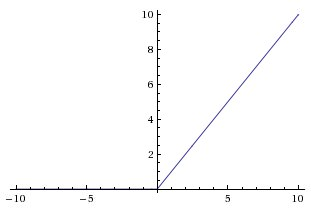

In [ ]:
# Here's a trick that researchers have discovered helps the network do better.
# We'll "turn off" some fraction of the neurons, at random, every time we run the network.
# It sounds strange, but by forcing the network to ignore, say, 20% of its neurons each time,
# we encourage the network to learn multiple pathways to find out the same answer.
# Dropout helps protect the model from memorizing or "overfitting" the training data.
# If you'd like, experiment later on with removing this line, or changing the percentage
# of neurons that are randomly ignored from 20% to something else, like 0% or 50%.
model.add(Dropout(0.2))

## Adding the second hidden layer

In [ ]:
# The second hidden layer appears identical to our first layer.
# However, instead of each of the 512-node receiving 784-inputs from the input image data,
# they receive 512 inputs from the output of the first 512-node layer.

model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.2))

## The Final Output Layer

In [ ]:
# The final layer of 10 neurons in fully-connected to the previous 512-node layer.
# The final layer of a fully connected neuron network should be equal to the number of desired classes (10 in this case).
model.add(Dense(10))

Now we need one last tool. We want the numbers in the final layer to add up to one (so that they represent a probability distribution). But applying ReLU won't help us to do that.

One idea is we could add everything up and divide by the sum. Example: (1, 2, 3) --> (1/6, 2/6, 3/6). But machine learning researchers have found out a different way that helps the network learn better.

The function is called "softmax". It's similar to our idea, but first it takes `exp(x)` of every number. This function "exp" means e^x, where e = 2.718... and e^x means "e to the power of x".

Example: (1, 2, 3) ---> (0.09, 0.25, 0.66), because
- 0.09 = e^1 / (e^1 + e^2 + e^3) = 2.718 / 30.19
- 0.25 = e^2 / (e^1 + e^2 + e^3) = 7.389 / 30.19
- 0.66 = e^3 / (e^1 + e^2 + e^3) = 20.09 / 30.19

**Exercise**: what would you get if you apply softmax to `(3, 0, 0, 2, 5)`? You'll want a calculator for this exercise.

In [ ]:
# Let's add the softmax activation to the final layer.

model.add(Activation('softmax'))

In [ ]:
# Run this code block to see a summary of the model we've constructed.

model.summary()

## Compiling the model

When compiing a model, Keras asks you to specify your **loss function** and your **optimizer**. The loss function we'll use here is called *categorical cross-entropy*, which is just another name for *negative log loss* which we discussed yesterday! This loss function is well-suited for comparing two probability distributions.

Our predictions are probability distributions across the ten different digits (e.g. "we're 80% confident this image is a 3, and 10% confident it's an 8, and 5% confident it's a 2, etc."), and the target is a probability distribution with 100% for the correct category, and 0 for everything else. The cross-entropy (negative log loss) is a measure of how different your predicted distribution is from the target distribution.

The optimizer helps determine how quickly the model learns through **gradient descent**. The rate at which descends a gradient is called the **learning rate**. Gradient descent means walking down the hill. The hill we walk down is defined by the loss function on pairs of (EXPECTED, PREDICTED) from the model.

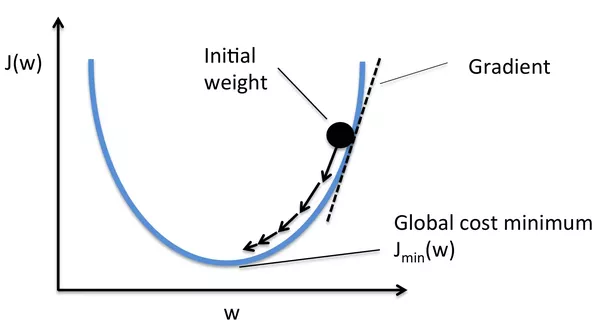

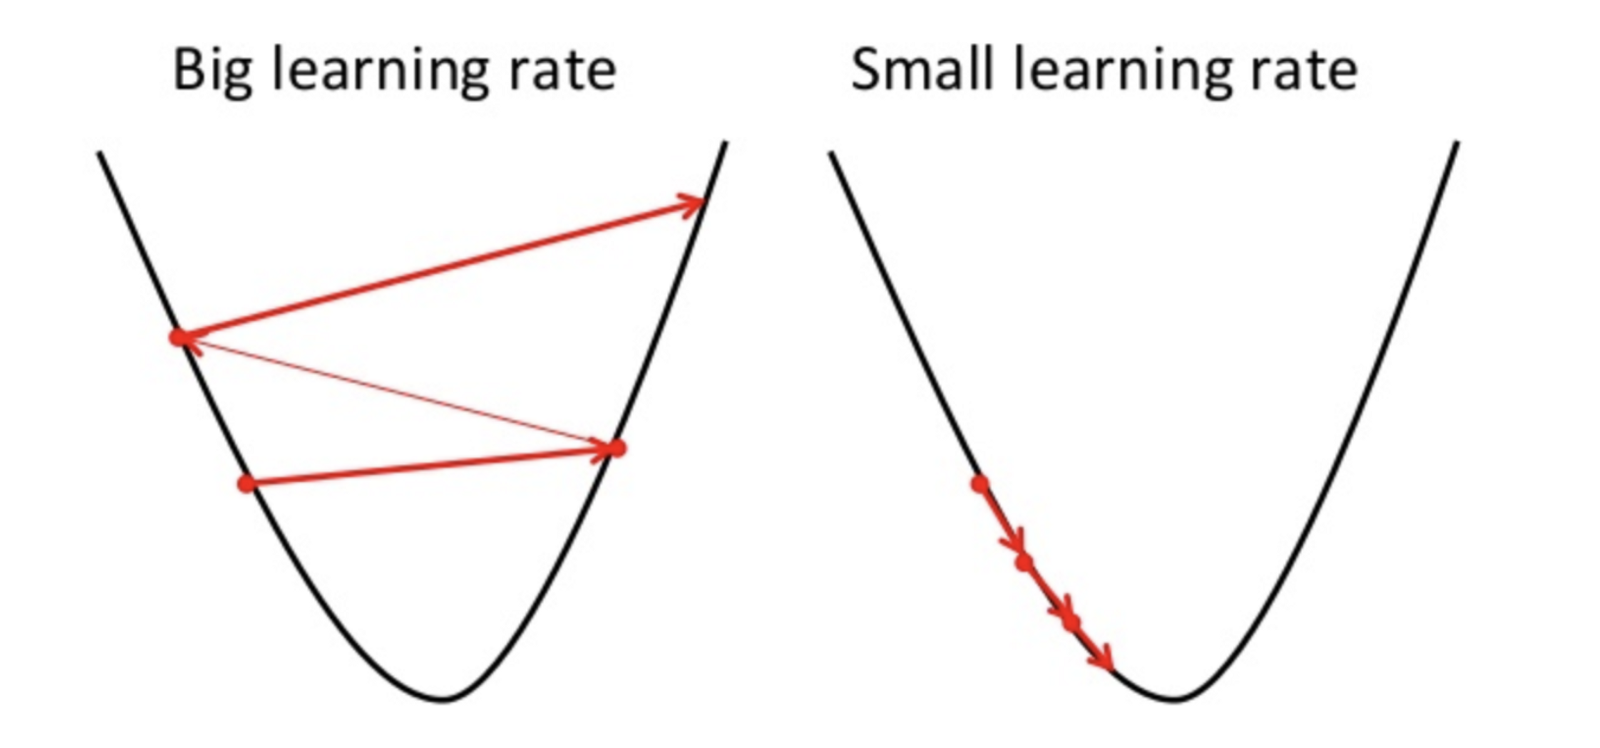

So are smaller learning rates better? Not quite! It's important for an optimizer not to get stuck in local minima while neglecting the global minimum of the loss function. Sometimes that means trying a larger learning rate to jump out of a local minimum.

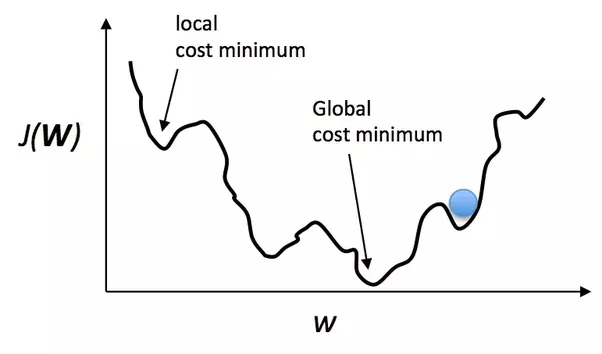

In [ ]:
# Let's use the Adam optimizer for learning
# Adam is like momentum gradient descent, but it incorporates even more ideas to help us hike downhill faster
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## Train the model!
This is the fun part!

The batch size determines over how much data per step to compute the gradient (direction to hike). For example, we could use one training example or ten at once.

Too large of a batch size smoothes the local minima of the loss function, causing the optimizer to settle in one because it thinks it found the global minimum.

Too small of a batch size creates a very noisy loss function, and the optimizer may never find the global minimum.

So a good batch size may take some trial and error to find! But batch gradient descent also answers the question, "How can we avoid getting stuck in a local minimum?" The answer is to inject a bit of randomness that can kick us out of suboptimal stopping points.

The "epochs" variable says how many times we will look at every training example. Here we will learn from every training example a total of five times.

In [ ]:
model.fit(X_train, Y_train,
          batch_size=128, epochs=5,
          verbose=1)

When you run this code, you'll see two numbers. They represent the value of the loss function of the network on the training set, and the overall accuracy of the network on the training data. Wow! Watch as the numbers go down.

But how does it do on data it did not train on?

## Evaluate Model's Accuracy on Test Data

In [ ]:
score = model.evaluate(X_test, Y_test)
print('Test score:', score[0])
print('Test accuracy:', score[1])

### Inspecting the output

It's always a good idea to inspect the output and make sure everything looks sane. Here we'll look at some examples it gets right, and some examples it gets wrong.

In [ ]:
# The predict_classes function outputs the highest probability class
# according to the trained classifier for each input example.
predict_x = model.predict(X_test)
predicted_classes = np.argmax(predict_x,axis=1)

# Check which items we got right / wrong
correct_indices = np.nonzero(predicted_classes == y_test)[0]

incorrect_indices = np.nonzero(predicted_classes != y_test)[0]

In [ ]:
plt.figure()
for i, correct in enumerate(correct_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct], y_test[correct]))

plt.tight_layout()

plt.figure()
for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[incorrect].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect], y_test[incorrect]))

plt.tight_layout()

## Congratulations!

You've come to the end of the neural network project. Now you have two options:

1. Help a friend. You'll learn a lot by listening to questions and answering them.
2. Experiment with different neural network architectures. What if you make hidden layers of size 32 instead of 512? What if you remove a hidden layer? What if you add another hidden layer? What if you remove dropout or make it stronger?

Have fun exploring!